Цель - получить первый воспроизводимый результат после EDA.

Используем события внутри суточного окна, удаляем полные дубли и собираем одну строку на cookie_id. 

Период 17-19 апреля не участвует в выборе признаков и параметров. Он используется один раз для финальной локальной проверки.

## Загружаем библиотеки и данные

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import catboost

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from metric import precision_at_recall, pr_curve, recall_at_fpr


In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
events_raw = pd.read_csv('data/events.csv.gz')
sample_submission = pd.read_csv('sample_submission.csv')

print('train', train.shape)
print('test', test.shape)
print('events', events_raw.shape)
print('sample_submission', sample_submission.shape)

train (11091, 5)
test (4909, 4)
events (328905, 14)
sample_submission (4909, 2)


## Повторяем подготовку событий из EDA

Временные поля переводим в datetime. Метаданные train и test объединяем без target. Объединение нужно только для одинаковой фильтрации событий по окну.

In [4]:
for frame in [train, test]:
    for column in ['cookie_created_at', 'window_start_ts', 'window_end_ts']:
        frame[column] = pd.to_datetime(frame[column])

events_raw['event_ts'] = pd.to_datetime(events_raw['event_ts'])

meta = pd.concat([
    train.drop(columns='target').assign(dataset='train'),
    test.assign(dataset='test')
], ignore_index=True)

meta['age_days'] = (
    meta['window_end_ts'] - meta['cookie_created_at']
).dt.total_seconds() / 86400

In [5]:
events_audit = events_raw.merge(
    meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
    on='cookie_id',
    validate='many_to_one'
)

inside_window = (
    events_audit['event_ts'].ge(events_audit['window_start_ts']) &
    events_audit['event_ts'].lt(events_audit['window_end_ts'])
)

events_window = events_audit.loc[inside_window, events_raw.columns].copy()
full_duplicates = events_window.duplicated()
events = events_window.loc[~full_duplicates].copy()

events['platform'] = (
    events['platform']
    .astype('string')
    .str.strip()
    .str.lower()
    .replace({'desktop': 'web', 'iphone': 'ios'})
)

events = events.sort_values(
    ['cookie_id', 'event_ts'],
    kind='stable'
).reset_index(drop=True)

preparation_result = pd.DataFrame({
    'Показатель': [
        'Исходные события',
        'События вне окна',
        'Полные дубли внутри окна',
        'События для признаков'
    ],
    'Значение': [
        len(events_raw),
        (~inside_window).sum(),
        full_duplicates.sum(),
        len(events)
    ]
})

display(preparation_result)

,Показатель,Значение
0,Исходные события,328905
1,События вне окна,40779
2,Полные дубли внутри окна,4293
3,События для признаков,283833


Для признаков осталось 283 833 события. Исключено 40 779 событий вне окна и 4 293 полных дубля.

## Создаём одну строку на куку

cookie_id остаётся индексом. window_start_ts нужен только для временного разбиения. В модель эти два поля не передаются.

In [6]:
cookie_features = meta.set_index('cookie_id')[
    ['dataset', 'window_start_ts', 'age_days']
].copy()

by_cookie = events.groupby('cookie_id')

cookie_features['n_events'] = by_cookie.size().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['n_items'] = by_cookie['item_id'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['platform'] = (
    by_cookie['platform']
    .first()
    .reindex(cookie_features.index)
    .fillna('unknown')
)

actions = sorted(events['event_name'].unique())

action_counts = pd.crosstab(
    events['cookie_id'],
    events['event_name']
).reindex(
    index=cookie_features.index,
    columns=actions,
    fill_value=0
)

for action in actions:
    cookie_features[f'n_{action}'] = action_counts[action]
    cookie_features[f'share_{action}'] = (
        action_counts[action] / cookie_features['n_events'].replace(0, np.nan)
    )

print('Типы событий', actions)
display(cookie_features.head())

Типы событий ['contact_chat_open', 'contact_message_sent', 'contact_phone_show', 'favorite_add', 'item_view', 'login', 'photo_swipe', 'search_results_view', 'seller_page_view']


,dataset,window_start_ts,age_days,n_events,n_items,platform,n_contact_chat_open,share_contact_chat_open,n_contact_message_sent,share_contact_message_sent,...,n_item_view,share_item_view,n_login,share_login,n_photo_swipe,share_photo_swipe,n_search_results_view,share_search_results_view,n_seller_page_view,share_seller_page_view
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,train,2026-04-06,136.603692,7,4,android,0,0.000000,0,0.000000,...,3,0.428571,0,0.000000,1,0.142857,3,0.428571,0,0.000000
ck_7e4de46eeab82974,train,2026-04-06,195.576111,41,19,web,0,0.000000,0,0.000000,...,22,0.536585,1,0.024390,4,0.097561,8,0.195122,4,0.097561
ck_9320229ef6304522,train,2026-04-06,33.994421,36,19,web,1,0.027778,1,0.027778,...,7,0.194444,3,0.083333,3,0.083333,13,0.361111,3,0.083333
ck_30ccd25bc1714ed9,train,2026-04-06,1.546759,21,10,web,1,0.047619,0,0.000000,...,14,0.666667,0,0.000000,0,0.000000,3,0.142857,2,0.095238
ck_a77c5f05948cdeef,train,2026-04-06,95.837095,28,16,web,0,0.000000,0,0.000000,...,12,0.428571,0,0.000000,4,0.142857,6,0.214286,3,0.107143


Количество действия описывает объём. Доля действия описывает состав истории. Оба варианта сохраняем.

## Добавляем ритм активности

EDA показал разницу в паузах и локальной скорости. Считаем активные минуты и часы, длину истории, квантили пауз и число сессий.

In [7]:
events['minute'] = events['event_ts'].dt.floor('min')
events['hour'] = events['event_ts'].dt.floor('h')

cookie_features['active_minutes'] = events.groupby('cookie_id')['minute'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['active_hours'] = events.groupby('cookie_id')['hour'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)

events_per_minute = events.groupby(['cookie_id', 'minute']).size()
cookie_features['max_events_minute'] = events_per_minute.groupby('cookie_id').max().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['active_minute_share'] = (
    cookie_features['max_events_minute'] /
    cookie_features['n_events'].replace(0, np.nan)
)

first_event = by_cookie['event_ts'].min()
last_event = by_cookie['event_ts'].max()
cookie_features['event_span_minutes'] = (
    last_event - first_event
).dt.total_seconds() / 60

events['gap_seconds'] = (
    events.groupby('cookie_id')['event_ts']
    .diff()
    .dt.total_seconds()
)

gaps = events.groupby('cookie_id')['gap_seconds']

cookie_features['gap_median'] = gaps.median()
cookie_features['gap_p10'] = gaps.quantile(0.10)
cookie_features['gap_q25'] = gaps.quantile(0.25)
cookie_features['gap_q75'] = gaps.quantile(0.75)
cookie_features['gap_p90'] = gaps.quantile(0.90)
cookie_features['gap_std'] = gaps.std()
cookie_features['gap_iqr'] = cookie_features['gap_q75'] - cookie_features['gap_q25']

known_gaps = events.loc[events['gap_seconds'].notna()]
cookie_features['fast_gap_share'] = (
    known_gaps['gap_seconds'].le(10)
    .groupby(known_gaps['cookie_id'])
    .mean()
)
cookie_features['zero_gap_share'] = (
    known_gaps['gap_seconds'].eq(0)
    .groupby(known_gaps['cookie_id'])
    .mean()
)

In [8]:
events['new_session'] = (
    events['gap_seconds'].isna() |
    events['gap_seconds'].gt(30 * 60)
)
events['session'] = events['new_session'].groupby(events['cookie_id']).cumsum()

sessions = events.groupby(['cookie_id', 'session']).agg(
    first_event=('event_ts', 'min'),
    last_event=('event_ts', 'max'),
    n_events=('event_ts', 'size')
)
sessions['duration_minutes'] = (
    sessions['last_event'] - sessions['first_event']
).dt.total_seconds() / 60

cookie_features['n_sessions'] = sessions.groupby(level=0).size().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['session_duration_median'] = sessions.groupby(level=0)[
    'duration_minutes'
].median()

У куки с одним событием интервалы остаются пропусками. CatBoost умеет работать с такими значениями. Ноль здесь означал бы событие без паузы и изменил смысл признака.

## Добавляем просмотры и интересы

Используем число объявлений, повторные просмотры, категории, локации и тип продавца. Концентрация считается среди известных значений.

In [9]:
item_views = events.loc[events['event_name'].eq('item_view')].copy()
item_groups = item_views.groupby('cookie_id')

cookie_features['unique_viewed_items'] = item_groups['item_id'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['repeat_view_share'] = (
    1 - cookie_features['unique_viewed_items'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)
cookie_features['unique_categories'] = item_groups['item_category'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['unique_locations'] = item_groups['item_location'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)

known_categories = item_views.dropna(subset=['item_category'])
known_locations = item_views.dropna(subset=['item_location'])

category_counts = known_categories.groupby(
    ['cookie_id', 'item_category']
).size()
location_counts = known_locations.groupby(
    ['cookie_id', 'item_location']
).size()

cookie_features['category_focus'] = (
    category_counts.groupby(level=0).max() /
    known_categories.groupby('cookie_id').size()
)
cookie_features['location_focus'] = (
    location_counts.groupby(level=0).max() /
    known_locations.groupby('cookie_id').size()
)
cookie_features['pro_seller_share'] = (
    item_views['seller_type'].eq('pro')
    .groupby(item_views['cookie_id'])
    .mean()
)

## Добавляем поиск и контакты

Глубина поиска оказалась полезнее самого наличия поиска. Контакты не разделяли классы сами по себе, но остаются частью поведения.

In [10]:
searches = events.loc[
    events['event_name'].eq('search_results_view')
].copy()

searches['query_normalized'] = (
    searches['search_query']
    .astype('string')
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .replace('', pd.NA)
)

search_groups = searches.groupby('cookie_id')

cookie_features['unique_queries'] = search_groups['query_normalized'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)
cookie_features['max_search_page'] = search_groups['search_page'].max()
cookie_features['mean_search_page'] = search_groups['search_page'].mean()
cookie_features['deep_search_share'] = (
    searches['search_page'].ge(5)
    .groupby(searches['cookie_id'])
    .mean()
)

contact_actions = [
    'contact_phone_show',
    'contact_chat_open',
    'contact_message_sent'
]

cookie_features['n_contacts'] = action_counts[contact_actions].sum(axis=1)
cookie_features['has_contact'] = cookie_features['n_contacts'].gt(0).astype(int)
cookie_features['contacts_per_view'] = (
    cookie_features['n_contacts'] /
    cookie_features['n_item_view'].replace(0, np.nan)
)

## Добавляем технические признаки

Возраст куки, платформа, User-Agent и координаты дали различия в EDA. Полный текст User-Agent не передаём. Используем число вариантов и фиксированный список технических маркеров.

In [11]:
cookie_features['n_user_agents'] = by_cookie['user_agent'].nunique().reindex(
    cookie_features.index,
    fill_value=0
)

automation_pattern = (
    r'headlesschrome|python-requests|python-urllib|scrapy|curl/|'
    r'go-http-client|node-fetch|wget|aiohttp|httpx'
)

events['has_automation_marker'] = (
    events['user_agent']
    .fillna('')
    .str.lower()
    .str.contains(automation_pattern, regex=True)
)

cookie_features['has_automation_marker'] = (
    events.groupby('cookie_id')['has_automation_marker']
    .any()
    .reindex(cookie_features.index, fill_value=False)
    .astype(int)
)

pointer_events = events.dropna(subset=['pointer_x', 'pointer_y']).groupby(
    'cookie_id'
).size()

cookie_features['pointer_share'] = (
    pointer_events.reindex(cookie_features.index, fill_value=0) /
    cookie_features['n_events'].replace(0, np.nan)
)

events['previous_event'] = events.groupby('cookie_id')['event_name'].shift()
events['previous_ts'] = events.groupby('cookie_id')['event_ts'].shift()

valid_transition = (
    events['previous_ts'].notna() &
    events['event_ts'].gt(events['previous_ts'])
)
same_action = (
    valid_transition &
    events['event_name'].eq(events['previous_event'])
)

transition_count = events.loc[valid_transition].groupby('cookie_id').size()
same_action_count = events.loc[same_action].groupby('cookie_id').size()

cookie_features['same_action_share'] = (
    same_action_count /
    transition_count.replace(0, np.nan)
)

## Проверяем таблицу признаков

Одна строка должна соответствовать одной куке. target не должен находиться в общей таблице. Бесконечные значения недопустимы.

In [12]:
numeric_values = cookie_features.select_dtypes('number').to_numpy()

feature_checks = pd.DataFrame({
    'Проверка': [
        'Одна строка на cookie_id',
        'Сохранены все куки',
        'target отсутствует в признаках',
        'Нет бесконечных значений',
        'Нет кук без событий'
    ],
    'Результат': [
        cookie_features.index.is_unique,
        len(cookie_features) == len(meta),
        'target' not in cookie_features.columns,
        not np.isinf(numeric_values).any(),
        cookie_features['n_events'].gt(0).all()
    ]
})

display(feature_checks)
print('Размер таблицы', cookie_features.shape)
print('Числовых пропусков', cookie_features.select_dtypes('number').isna().sum().sum())

,Проверка,Результат
0,Одна строка на cookie_id,True
1,Сохранены все куки,True
2,target отсутствует в признаках,True
3,Нет бесконечных значений,True
4,Нет кук без событий,True


Размер таблицы (16000, 58)
Числовых пропусков 15920


Пропуски остаются только там, где показатель нельзя посчитать. Они не заменяются нулём автоматически.

## Разделяем признаки на группы

Так можно проверить вклад каждого блока. Порядок групп повторяет выводы EDA.

In [13]:
volume_features = [
    'n_events',
    'n_items',
    'active_minutes',
    'active_hours',
    'event_span_minutes'
]

rhythm_features = [
    'max_events_minute',
    'active_minute_share',
    'gap_median',
    'gap_p10',
    'gap_q25',
    'gap_q75',
    'gap_p90',
    'gap_std',
    'gap_iqr',
    'fast_gap_share',
    'zero_gap_share',
    'n_sessions',
    'session_duration_median'
]

action_features = (
    [f'n_{action}' for action in actions] +
    [f'share_{action}' for action in actions] +
    ['n_contacts', 'has_contact', 'contacts_per_view']
)

interest_features = [
    'unique_viewed_items',
    'repeat_view_share',
    'unique_categories',
    'unique_locations',
    'category_focus',
    'location_focus',
    'pro_seller_share',
    'unique_queries',
    'max_search_page',
    'mean_search_page',
    'deep_search_share',
    'same_action_share'
]

technical_features = [
    'age_days',
    'platform',
    'n_user_agents',
    'has_automation_marker',
    'pointer_share'
]

feature_sets = {
    'volume': volume_features,
    'volume_rhythm': volume_features + rhythm_features,
    'behavior': volume_features + rhythm_features + action_features,
    'content_search': volume_features + rhythm_features + action_features + interest_features,
    'all': volume_features + rhythm_features + action_features + interest_features + technical_features
}

pd.DataFrame({
    'Набор': feature_sets.keys(),
    'Число признаков': [len(columns) for columns in feature_sets.values()]
})

,Набор,Число признаков
0,volume,5
1,volume_rhythm,18
2,behavior,39
3,content_search,51
4,all,56


## Готовим временные разбиения

Первое разбиение проверяет модель на 10-12 апреля. Второе разбиение проверяет её на 13-16 апреля. Обучающая часть всегда находится раньше проверочной.

In [14]:
labels = train.set_index('cookie_id')['target']
model_data = cookie_features.loc[labels.index].join(
    labels,
    validate='one_to_one'
)

folds = [
    ('fold_1', pd.Timestamp('2026-04-10'), pd.Timestamp('2026-04-13')),
    ('fold_2', pd.Timestamp('2026-04-13'), pd.Timestamp('2026-04-17'))
]

fold_rows = []

for fold_name, valid_start, valid_end in folds:
    train_mask = model_data['window_start_ts'].lt(valid_start)
    valid_mask = (
        model_data['window_start_ts'].ge(valid_start) &
        model_data['window_start_ts'].lt(valid_end)
    )
    fold_rows.append([
        fold_name,
        model_data.loc[train_mask, 'window_start_ts'].min(),
        model_data.loc[train_mask, 'window_start_ts'].max(),
        train_mask.sum(),
        model_data.loc[train_mask, 'target'].sum(),
        model_data.loc[valid_mask, 'window_start_ts'].min(),
        model_data.loc[valid_mask, 'window_start_ts'].max(),
        valid_mask.sum(),
        model_data.loc[valid_mask, 'target'].sum()
    ])

fold_table = pd.DataFrame(
    fold_rows,
    columns=[
        'Разбиение', 'Начало обучения', 'Конец обучения',
        'Кук в обучении', 'Ботов в обучении',
        'Начало проверки', 'Конец проверки',
        'Кук в проверке', 'Ботов в проверке'
    ]
)

display(fold_table)

,Разбиение,Начало обучения,Конец обучения,Кук в обучении,Ботов в обучении,Начало проверки,Конец проверки,Кук в проверке,Ботов в проверке
0,fold_1,2026-04-06,2026-04-09,3305,263,2026-04-10,2026-04-12,2625,228
1,fold_2,2026-04-06,2026-04-12,5930,491,2026-04-13,2026-04-16,3210,248


В первом разбиении 228 положительных примеров на проверке, во втором - 248. Этого достаточно для сравнения базовых вариантов, но метрика всё равно может заметно меняться между периодами.

## Считаем результат постоянного score

Постоянный score не ранжирует куки. Его Precision @ Recall >= 0.70 совпадает с долей положительного класса.

In [15]:
constant_rows = []

for fold_name, valid_start, valid_end in folds:
    valid_mask = (
        model_data['window_start_ts'].ge(valid_start) &
        model_data['window_start_ts'].lt(valid_end)
    )
    y_valid = model_data.loc[valid_mask, 'target']
    constant_score = np.full(len(y_valid), 0.5)
    constant_rows.append([
        fold_name,
        len(y_valid),
        y_valid.sum(),
        y_valid.mean(),
        precision_at_recall(y_valid, constant_score)
    ])

constant_results = pd.DataFrame(
    constant_rows,
    columns=['Разбиение', 'Кук', 'Ботов', 'Доля ботов', 'Основная метрика']
)

display(constant_results.round(4))

,Разбиение,Кук,Ботов,Доля ботов,Основная метрика
0,fold_1,2625,228,0.0869,0.0869
1,fold_2,3210,248,0.0773,0.0773


Постоянная модель получает около 0,08. Полезная модель должна заметно превысить этот уровень на обоих временных разбиениях.

## Проверяем вклад групп признаков

CatBoost подходит для числовых признаков, пропусков и платформы. Во всех экспериментах используются одинаковые параметры. Меняется только набор столбцов.

In [16]:
ablation_rows = []

for set_name, feature_columns in feature_sets.items():
    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        X_train = model_data.loc[train_mask, feature_columns]
        y_train = model_data.loc[train_mask, 'target']
        X_valid = model_data.loc[valid_mask, feature_columns]
        y_valid = model_data.loc[valid_mask, 'target']

        categorical_features = []
        if 'platform' in feature_columns:
            categorical_features = ['platform']

        model = CatBoostClassifier(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            X_train,
            y_train,
            cat_features=categorical_features,
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=80,
            verbose=False
        )

        valid_score = model.predict_proba(X_valid)[:, 1]

        ablation_rows.append([
            set_name,
            fold_name,
            len(feature_columns),
            model.get_best_iteration() + 1,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score),
            recall_at_fpr(y_valid, valid_score)
        ])

ablation_results = pd.DataFrame(
    ablation_rows,
    columns=[
        'Набор', 'Разбиение', 'Признаков', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC', 'Recall при FPR 0.01'
    ]
)

display(ablation_results.round(4))

,Набор,Разбиение,Признаков,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,volume,fold_1,5,132,0.1575,0.5028,0.7556,0.3377
1,volume,fold_2,5,216,0.1642,0.4790,0.7745,0.3185
2,volume_rhythm,fold_1,18,80,0.3152,0.6334,0.8491,0.4561
3,volume_rhythm,fold_2,18,328,0.2995,0.6131,0.8614,0.4355
4,behavior,fold_1,39,252,0.4598,0.6750,0.8592,0.4956
5,behavior,fold_2,39,243,0.3527,0.6488,0.8788,0.4839
6,content_search,fold_1,51,204,0.5263,0.6910,0.8629,0.5132
7,content_search,fold_2,51,220,0.4065,0.6670,0.8811,0.5040
8,all,fold_1,56,218,0.5442,0.6961,0.8674,0.5263
9,all,fold_2,56,209,0.4335,0.6704,0.8857,0.5081


,metric_mean,metric_min,pr_auc_mean,roc_auc_mean
Набор,,,,
all,0.4889,0.4335,0.6833,0.8766
content_search,0.4664,0.4065,0.6790,0.8720
behavior,0.4062,0.3527,0.6619,0.8690
volume_rhythm,0.3073,0.2995,0.6232,0.8553
volume,0.1608,0.1575,0.4909,0.7650


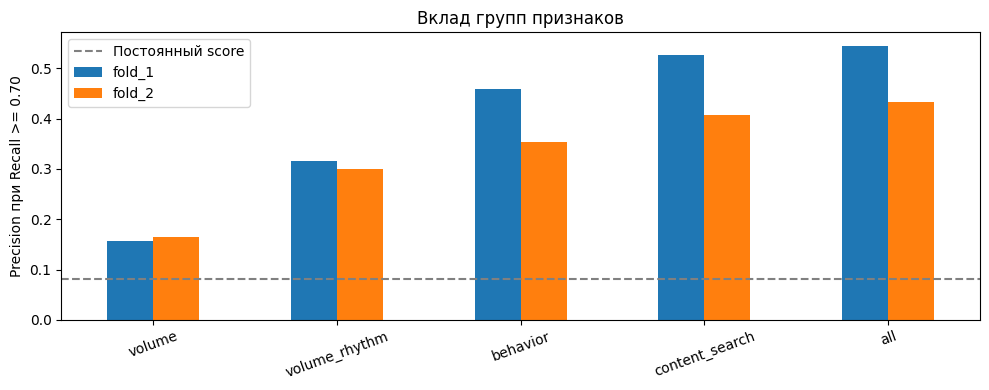

In [17]:
ablation_summary = ablation_results.groupby('Набор').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    roc_auc_mean=('ROC-AUC', 'mean')
).sort_values('metric_mean', ascending=False)

display(ablation_summary.round(4))

ax = ablation_results.pivot(
    index='Набор',
    columns='Разбиение',
    values='Precision при Recall 0.70'
).loc[list(feature_sets)].plot.bar(figsize=(10, 4), rot=20)

ax.axhline(
    constant_results['Основная метрика'].mean(),
    color='gray',
    linestyle='--',
    label='Постоянный score'
)
ax.set(xlabel='', ylabel='Precision при Recall >= 0.70', title='Вклад групп признаков')
ax.legend()
plt.tight_layout()
plt.show()

Объём активности даёт среднюю метрику около 0,16. Признаки ритма повышают её до 0,31. Состав действий даёт 0,41, интересы и поиск - 0,47, полный набор - 0,49.

Каждая группа улучшает результат на обоих разбиениях. Для первой модели оставляем все 56 признаков.

## Проверяем вес положительного класса

Положительный класс занимает около 8% данных. Вес 1 означает обычное обучение. Веса 2 и 4 сильнее учитывают ошибки на положительном классе. Глубина дерева и остальные параметры не меняются.

In [18]:
all_features = feature_sets['all']
weight_rows = []
weight_models = {}

for positive_weight in [1, 2, 4]:
    for fold_name, valid_start, valid_end in folds:
        train_mask = model_data['window_start_ts'].lt(valid_start)
        valid_mask = (
            model_data['window_start_ts'].ge(valid_start) &
            model_data['window_start_ts'].lt(valid_end)
        )

        X_train = model_data.loc[train_mask, all_features]
        y_train = model_data.loc[train_mask, 'target']
        X_valid = model_data.loc[valid_mask, all_features]
        y_valid = model_data.loc[valid_mask, 'target']

        model = CatBoostClassifier(
            iterations=600,
            depth=6,
            learning_rate=0.05,
            loss_function='Logloss',
            eval_metric='PRAUC:type=Classic',
            class_weights=[1, positive_weight],
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            X_train,
            y_train,
            cat_features=['platform'],
            eval_set=(X_valid, y_valid),
            early_stopping_rounds=100,
            verbose=False
        )

        valid_score = model.predict_proba(X_valid)[:, 1]

        weight_rows.append([
            positive_weight,
            fold_name,
            model.get_best_iteration() + 1,
            precision_at_recall(y_valid, valid_score),
            average_precision_score(y_valid, valid_score),
            roc_auc_score(y_valid, valid_score)
        ])

        weight_models[(positive_weight, fold_name)] = (
            model,
            valid_score,
            y_valid.copy(),
            X_valid.index
        )

weight_results = pd.DataFrame(
    weight_rows,
    columns=[
        'Вес положительного класса', 'Разбиение', 'Итераций',
        'Precision при Recall 0.70', 'PR-AUC', 'ROC-AUC'
    ]
)

display(weight_results.round(4))

,Вес положительного класса,Разбиение,Итераций,Precision при Recall 0.70,PR-AUC,ROC-AUC
0,1,fold_1,218,0.5442,0.6961,0.8674
1,1,fold_2,209,0.4335,0.6704,0.8857
2,2,fold_1,206,0.5000,0.6890,0.8630
3,2,fold_2,244,0.4275,0.6746,0.8907
4,4,fold_1,285,0.5195,0.6973,0.8717
5,4,fold_2,194,0.4450,0.6729,0.8931


In [19]:
weight_summary = weight_results.groupby('Вес положительного класса').agg(
    metric_mean=('Precision при Recall 0.70', 'mean'),
    metric_min=('Precision при Recall 0.70', 'min'),
    pr_auc_mean=('PR-AUC', 'mean'),
    best_iterations=('Итераций', 'median')
).sort_values('metric_mean', ascending=False)

display(weight_summary.round(4))

selected_weight = int(weight_summary.index[0])
selected_iterations = int(
    weight_results.loc[
        weight_results['Вес положительного класса'].eq(selected_weight),
        'Итераций'
    ].median()
)

validation_model, validation_score, validation_target, validation_index = weight_models[(
    selected_weight,
    'fold_2'
)]

print('Выбранный вес', selected_weight)
print('Число итераций для финального обучения', selected_iterations)

,metric_mean,metric_min,pr_auc_mean,best_iterations
Вес положительного класса,,,,
1,0.4889,0.4335,0.6833,213.5
4,0.4822,0.4450,0.6851,239.5
2,0.4638,0.4275,0.6818,225.0


Выбранный вес 1
Число итераций для финального обучения 213


Вес 1 даёт лучшую среднюю основную метрику. Дополнительный вес положительного класса не улучшил результат на двух разбиениях.

Результаты выбранного варианта равны 0,5442 и 0,4335. Для дальнейшего обучения используем 213 итераций. Число итераций получено как медиана двух временных разбиений.

## Смотрим важность признаков на втором разбиении

Важность показывает, какие столбцы CatBoost чаще использовал в деревьях. Она не доказывает причинную связь и может делиться между коррелирующими признаками.

,Признак,Важность
17,session_duration_median,5.970
10,gap_q75,4.929
48,mean_search_page,4.645
7,gap_median,4.336
8,gap_p10,4.112
13,gap_iqr,4.083
43,category_focus,3.541
9,gap_q25,3.248
51,age_days,3.248
30,share_favorite_add,2.985


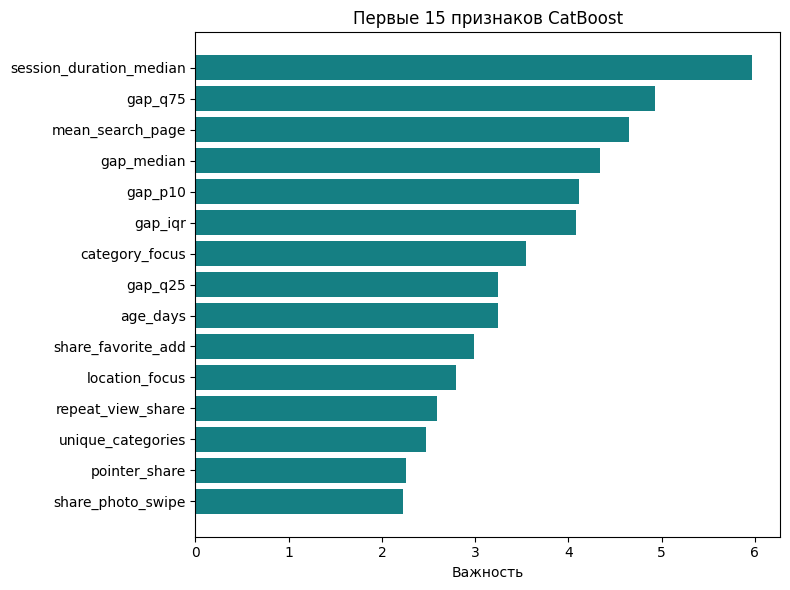

In [20]:
feature_importance = pd.DataFrame({
    'Признак': all_features,
    'Важность': validation_model.get_feature_importance()
}).sort_values('Важность', ascending=False)

display(feature_importance.head(20).round(3))

plot_importance = feature_importance.head(15).sort_values('Важность')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_importance['Признак'], plot_importance['Важность'], color='#157F83')
ax.set(xlabel='Важность', ylabel='', title='Первые 15 признаков CatBoost')
plt.tight_layout()
plt.show()

В верхней части списка находятся паузы, глубина поиска, концентрация по категориям и разнообразие объектов. Модель использует несколько групп из EDA, а не только число событий.

## Находим рабочую точку на валидации

Порог нужен только для разбора ошибок. В submission отправляется непрерывный score. Платформа перебирает пороги самостоятельно.

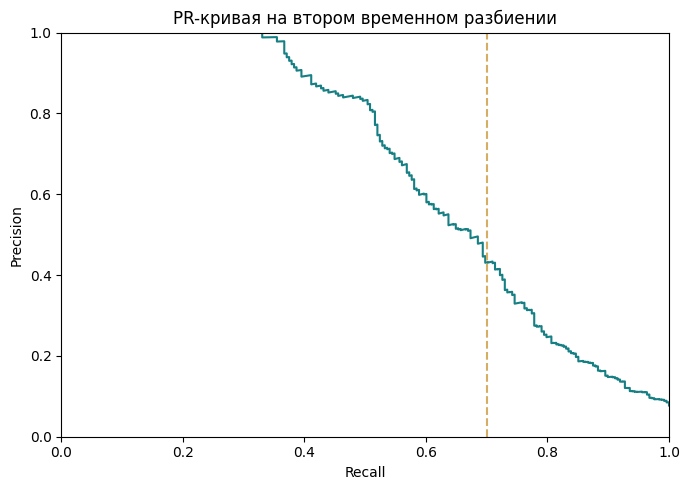

,Порог,Precision,Recall,Отмечено кук,Всего положительных
0,0.0983,0.4335,0.7097,406,248


In [21]:
precision, recall = pr_curve(validation_target, validation_score)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='#157F83')
ax.axvline(0.70, color='#D5AD63', linestyle='--')
ax.set(
    xlabel='Recall',
    ylabel='Precision',
    title='PR-кривая на втором временном разбиении',
    xlim=(0, 1),
    ylim=(0, 1)
)
plt.tight_layout()
plt.show()

order = np.argsort(-validation_score, kind='mergesort')
y_sorted = validation_target.to_numpy()[order]
score_sorted = validation_score[order]

true_positive = np.cumsum(y_sorted)
marked = np.arange(1, len(y_sorted) + 1)
group_ends = np.r_[score_sorted[1:] != score_sorted[:-1], True]

thresholds = score_sorted[group_ends]
threshold_precision = true_positive[group_ends] / marked[group_ends]
threshold_recall = true_positive[group_ends] / y_sorted.sum()

allowed = threshold_recall >= 0.70
allowed_positions = np.where(allowed)[0]
best_position = allowed_positions[np.argmax(threshold_precision[allowed])]

validation_threshold = thresholds[best_position]
validation_prediction = validation_score >= validation_threshold

threshold_table = pd.DataFrame({
    'Порог': [validation_threshold],
    'Precision': [threshold_precision[best_position]],
    'Recall': [threshold_recall[best_position]],
    'Отмечено кук': [validation_prediction.sum()],
    'Всего положительных': [validation_target.sum()]
})

display(threshold_table.round(4))

На втором разбиении модель достигает recall не ниже 0,70 без отметки большей части выборки. Порог относится только к этому периоду и не переносится в submission.

## Разбираем ошибки на валидации

Сравниваем найденных и пропущенных ботов с ложными срабатываниями. Разбор проводится на втором разбиении, а не на финальном периоде 17-19 апреля.

In [22]:
validation_errors = model_data.loc[
    validation_index,
    [
        'platform',
        'n_events',
        'gap_median',
        'max_search_page',
        'age_days',
        'category_focus',
        'unique_locations',
        'target'
    ]
].copy()

validation_errors['score'] = validation_score
validation_errors['prediction'] = validation_prediction.astype(int)

validation_errors['group'] = np.select(
    [
        validation_errors['target'].eq(1) & validation_errors['prediction'].eq(1),
        validation_errors['target'].eq(1) & validation_errors['prediction'].eq(0),
        validation_errors['target'].eq(0) & validation_errors['prediction'].eq(1)
    ],
    [
        'Найденный бот',
        'Пропущенный бот',
        'Ложное срабатывание'
    ],
    default='Верный человек'
)

error_summary = validation_errors.groupby('group').agg(
    cookies=('target', 'size'),
    score_median=('score', 'median'),
    events_median=('n_events', 'median'),
    gap_median=('gap_median', 'median'),
    max_page_median=('max_search_page', 'median'),
    age_median=('age_days', 'median'),
    locations_median=('unique_locations', 'median')
)

display(error_summary.round(2))
display(pd.crosstab(validation_errors['group'], validation_errors['platform']))

,cookies,score_median,events_median,gap_median,max_page_median,age_median,locations_median
group,,,,,,,
Верный человек,2732,0.02,11.0,64.75,3.0,67.06,2.0
Ложное срабатывание,230,0.17,19.0,28.00,7.0,32.10,4.0
Найденный бот,176,0.81,26.5,18.50,8.0,5.01,6.0
Пропущенный бот,72,0.04,12.0,47.00,4.0,58.26,3.0


platform,android,ios,web
group,,,
Верный человек,1208,130,1394
Ложное срабатывание,92,11,127
Найденный бот,45,4,127
Пропущенный бот,27,1,44


Пропущенные боты ближе к человеческим кукам по объёму, паузам и возрасту. Ложные срабатывания чаще похожи на найденных ботов по скорости и глубине поиска. Следующее улучшение должно искать признаки для этих пересекающихся групп, а не усиливать уже очевидные экстремальные случаи.

## Проводим финальную локальную проверку

Модель обучается на 6-16 апреля. Период 17-19 апреля используется только для оценки. Параметры и число итераций уже выбраны по двум предыдущим разбиениям.

In [23]:
development_mask = model_data['window_start_ts'].lt(
    pd.Timestamp('2026-04-17')
)
holdout_mask = model_data['window_start_ts'].ge(
    pd.Timestamp('2026-04-17')
)

X_development = model_data.loc[development_mask, all_features]
y_development = model_data.loc[development_mask, 'target']
X_holdout = model_data.loc[holdout_mask, all_features]
y_holdout = model_data.loc[holdout_mask, 'target']

holdout_model = CatBoostClassifier(
    iterations=selected_iterations,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    class_weights=[1, selected_weight],
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

holdout_model.fit(
    X_development,
    y_development,
    cat_features=['platform'],
    verbose=False
)

holdout_score = holdout_model.predict_proba(X_holdout)[:, 1]

holdout_results = pd.DataFrame({
    'Период': ['17-19 апреля'],
    'Кук': [len(y_holdout)],
    'Ботов': [y_holdout.sum()],
    'Precision при Recall 0.70': [precision_at_recall(y_holdout, holdout_score)],
    'PR-AUC': [average_precision_score(y_holdout, holdout_score)],
    'ROC-AUC': [roc_auc_score(y_holdout, holdout_score)],
    'Recall при FPR 0.01': [recall_at_fpr(y_holdout, holdout_score)]
})

display(holdout_results.round(4))

,Период,Кук,Ботов,Precision при Recall 0.70,PR-AUC,ROC-AUC,Recall при FPR 0.01
0,17-19 апреля,1951,160,0.4766,0.6967,0.8965,0.5


На периоде 17-19 апреля основная метрика равна 0,4766. PR-AUC равен 0,6967, ROC-AUC - 0,8965. Результат находится в диапазоне двух временных валидаций и заметно выше постоянного score.

После этой проверки модель и признаки не меняются по результатам holdout. Новые идеи нужно снова оценивать на внутренних разбиениях.

## Обучаем модель на всём train

Финальная модель использует 6-19 апреля. Для test рассчитывается score класса 1. Порог не применяется.

In [24]:
X_full_train = model_data[all_features]
y_full_train = model_data['target']
X_test = cookie_features.loc[test['cookie_id'], all_features]

final_model = CatBoostClassifier(
    iterations=selected_iterations,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    class_weights=[1, selected_weight],
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

final_model.fit(
    X_full_train,
    y_full_train,
    cat_features=['platform'],
    verbose=False
)

test_score = final_model.predict_proba(X_test)[:, 1]

test_scores = pd.Series(
    test_score,
    index=X_test.index,
    name='score'
)

submission = sample_submission[['cookie_id']].copy()
submission['score'] = submission['cookie_id'].map(test_scores)
submission['score'] = submission['score'].clip(0, 1)

submission.to_csv('baseline_submission.csv', index=False)

display(submission.head())

,cookie_id,score
0,ck_99a4e5ef02d89493,0.031354
1,ck_54d463f7fd89ec3d,0.030471
2,ck_0fbbc7a6af300368,0.024230
3,ck_8fd4937eadd64fb6,0.069450
4,ck_dbb4bd4eda97255d,0.030177


In [25]:
submission_checks = pd.DataFrame({
    'Проверка': [
        'Число строк совпадает с test',
        'Нет повторных cookie_id',
        'Нет пропусков',
        'Все cookie_id принадлежат test',
        'Все score находятся от 0 до 1'
    ],
    'Результат': [
        len(submission) == len(test),
        not submission['cookie_id'].duplicated().any(),
        submission.notna().all().all(),
        set(submission['cookie_id']) == set(test['cookie_id']),
        submission['score'].between(0, 1).all()
    ]
})

display(submission_checks)
print('Минимальный score', submission['score'].min())
print('Максимальный score', submission['score'].max())

,Проверка,Результат
0,Число строк совпадает с test,True
1,Нет повторных cookie_id,True
2,Нет пропусков,True
3,Все cookie_id принадлежат test,True
4,Все score находятся от 0 до 1,True


Минимальный score 0.0019251751229300048
Максимальный score 0.9976687338194447


## Результаы

Основная локальная метрика на 17-19 апреля равна 0,4766 при базовом уровне около 0,08.

Модель использует все группы признаков из EDA. Наибольший прирост дали ритм, состав действий, интересы и поиск. Технические признаки дали дополнительное улучшение